# Full-profile production-candidate retraining

This notebook performs the final large-scale retraining stage for the household electricity forecasting SaaS.

It trains a **global univariate household model**: each sample contains one household's consumption history and target, while batches mix windows from many households. The application input contract remains:

```text
timestamp + energy_kwh
```

Calendar features are derived by the backend and by this training pipeline.

## Scope of this run

The balanced experiment evaluated five architectures across three horizons. This full-profile run intentionally trains only the selected production candidates:

| Product horizon | Primary candidate | Fallback candidate |
|---|---|---|
| Next day — 24 hours | Global TFT | Global N-BEATS |
| Next week — 168 hours | Global TFT | Global N-BEATS |
| Next month — 30 daily totals | Global N-BEATS | MultiCycleNet-adapted |

N-BEATS cluster localization is disabled because it did not improve the balanced-run results. The worker retains localization support for research reproducibility, but this production-candidate experiment uses the shared global checkpoint.

## Full profile

- up to **2,500 households**;
- **48 sampled windows per household per epoch**;
- up to **15 epochs** with early stopping;
- **24 evaluation origins per household**;
- dual-T4 scheduling with one isolated process per job;
- resumable outputs isolated under `full_selected_v1`.


## Research alignment

The implemented architectures follow the same research-aligned designs validated in the balanced run:

- **Global TFT**: variable selection, LSTM encoder/decoder, gated residual blocks, causal attention, and 0.1/0.5/0.9 quantiles.
- **Global N-BEATS**: shared global backbone with calendar-aware first block and residual refinement.
- **MultiCycleNet-adapted**: nine historical cycles with contextual values and direct multi-horizon prediction.

The original benchmark architectures remain available in the worker, but PatchTST and the generic Transformer are excluded from this expensive full-profile run because they were not selected after balanced evaluation.


## Kaggle data

Attach:

```text
jeanmidev/smart-meters-in-london
```

This notebook is configured for:

```text
/kaggle/input/datasets/jeanmidev/smart-meters-in-london/halfhourly_dataset/halfhourly_dataset
```

The preprocessing supports both common layouts.

### Long layout

```text
LCLid | tstp | energy(kWh/hh)
```

### Wide daily layout

```text
LCLid | day | hh_0 | hh_1 | ... | hh_47
```

For the wide layout, `hh_0` is 00:00, `hh_1` is 00:30, and `hh_47`
is 23:30. Half-hour readings are summed into hourly kWh.

The monthly task predicts 30 daily totals instead of 720 individual
hourly values.


In [1]:
# =========================================
# 1. EXPERIMENT CONFIGURATION
# =========================================
from pathlib import Path
import json

DATA_ROOT = Path(
    "/kaggle/input/datasets/jeanmidev/"
    "smart-meters-in-london/"
    "halfhourly_dataset/"
    "halfhourly_dataset"
)

EXPERIMENT_NAME = "full_selected_v1"
BASE_WORK_ROOT = Path("/kaggle/working/lcl_global_forecasting")
WORK_ROOT = BASE_WORK_ROOT / EXPERIMENT_NAME
DATA_DIR = WORK_ROOT / "data"
RUNS_DIR = WORK_ROOT / "runs"
LOGS_DIR = WORK_ROOT / "logs"

for path in [WORK_ROOT, DATA_DIR, RUNS_DIR, LOGS_DIR]:
    path.mkdir(parents=True, exist_ok=True)

SEED = 2026
YEAR = 2013
RUN_PROFILE = "full"

PROFILES = {
    "smoke": dict(
        max_households=80,
        samples_per_household=4,
        eval_origins=2,
        epochs=1,
        patience=1,
    ),
    "balanced": dict(
        max_households=800,
        samples_per_household=24,
        eval_origins=12,
        epochs=8,
        patience=3,
    ),
    "full": dict(
        max_households=2500,
        samples_per_household=48,
        eval_origins=24,
        epochs=15,
        patience=5,
    ),
}

PROFILE = PROFILES[RUN_PROFILE]
MAX_HOUSEHOLDS = PROFILE["max_households"]
SAMPLES_PER_HOUSEHOLD = PROFILE["samples_per_household"]
EVAL_ORIGINS_PER_HOUSEHOLD = PROFILE["eval_origins"]
MAX_EPOCHS = PROFILE["epochs"]
PATIENCE = PROFILE["patience"]

MIN_COMPLETENESS = 0.95
COLD_HOUSEHOLD_FRACTION = 0.20

BATCH_SIZE = 128
NUM_WORKERS = 2
MAX_PARALLEL_JOBS = 2
RESUME = True

# Localization was slightly worse than the shared global N-BEATS model
# in every balanced-run cohort, so it is disabled for production retraining.
RUN_NBEATS_LOCALIZATION = False
N_LOCAL_CLUSTERS = 4
LOCALIZATION_EPOCHS = 2

SELECTED_RUNS = [
    {"model": "global_tft", "task": "day_24h", "role": "primary"},
    {"model": "global_nbeats_localized", "task": "day_24h", "role": "fallback"},
    {"model": "global_tft", "task": "week_168h", "role": "primary"},
    {"model": "global_nbeats_localized", "task": "week_168h", "role": "fallback"},
    {"model": "global_nbeats_localized", "task": "month_30d", "role": "primary"},
    {"model": "multicyclenet_adapted", "task": "month_30d", "role": "fallback"},
]

MODELS = list(dict.fromkeys(run["model"] for run in SELECTED_RUNS))
TASKS = list(dict.fromkeys(run["task"] for run in SELECTED_RUNS))

if not DATA_ROOT.exists():
    raise FileNotFoundError(
        "The configured Low Carbon London directory does not exist:\n"
        f"{DATA_ROOT}\n\n"
        "Attach 'jeanmidev/smart-meters-in-london' and verify the path."
    )

BLOCK_FILES = sorted(DATA_ROOT.rglob("block_*.csv"))
assert BLOCK_FILES, (
    f"No block_*.csv files were found under {DATA_ROOT}. "
    "Inspect the Kaggle input directory and update DATA_ROOT if needed."
)

experiment_manifest = {
    "experiment_name": EXPERIMENT_NAME,
    "run_profile": RUN_PROFILE,
    "profile": PROFILE,
    "selected_runs": SELECTED_RUNS,
    "n_selected_runs": len(SELECTED_RUNS),
    "nbeats_localization": RUN_NBEATS_LOCALIZATION,
    "seed": SEED,
    "year": YEAR,
    "dataset_directory": str(DATA_ROOT),
}
(WORK_ROOT / "experiment_manifest.json").write_text(
    json.dumps(experiment_manifest, indent=2)
)

print(json.dumps(experiment_manifest, indent=2))
print("Block CSV files found:", len(BLOCK_FILES))
print("First block files:", BLOCK_FILES[:3])
print("Work root:", WORK_ROOT)


{
  "experiment_name": "full_selected_v1",
  "run_profile": "full",
  "profile": {
    "max_households": 2500,
    "samples_per_household": 48,
    "eval_origins": 24,
    "epochs": 15,
    "patience": 5
  },
  "selected_runs": [
    {
      "model": "global_tft",
      "task": "day_24h",
      "role": "primary"
    },
    {
      "model": "global_nbeats_localized",
      "task": "day_24h",
      "role": "fallback"
    },
    {
      "model": "global_tft",
      "task": "week_168h",
      "role": "primary"
    },
    {
      "model": "global_nbeats_localized",
      "task": "week_168h",
      "role": "fallback"
    },
    {
      "model": "global_nbeats_localized",
      "task": "month_30d",
      "role": "primary"
    },
    {
      "model": "multicyclenet_adapted",
      "task": "month_30d",
      "role": "fallback"
    }
  ],
  "n_selected_runs": 6,
  "nbeats_localization": false,
  "seed": 2026,
  "year": 2013,
  "dataset_directory": "/kaggle/input/datasets/jeanmidev/smart-meters-i

In [2]:
%%capture install_output
# =========================================
# 2. DEPENDENCIES
# =========================================
import subprocess, sys
subprocess.run([
    sys.executable, '-m', 'pip', 'install', '--quiet',
    'holidays>=0.70', 'scikit-learn>=1.4', 'pyarrow>=15', 'psutil'
], check=True)
print('Dependencies installed.')

In [3]:
# =========================================
# 3. GPU CHECK
# =========================================
import platform, random
import numpy as np
import torch

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

print('Python:', platform.python_version())
print('PyTorch:', torch.__version__)
print('CUDA:', torch.version.cuda)
print('GPU count:', torch.cuda.device_count())
for index in range(torch.cuda.device_count()):
    props = torch.cuda.get_device_properties(index)
    print(f'GPU {index}: {props.name} | {props.total_memory / 1024**3:.1f} GiB')
assert torch.cuda.is_available()
assert torch.cuda.device_count() >= 2, 'Select Kaggle GPU T4 x2.'

Python: 3.12.13
PyTorch: 2.10.0+cu128
CUDA: 12.8
GPU count: 2
GPU 0: Tesla T4 | 14.6 GiB
GPU 1: Tesla T4 | 14.6 GiB


## Split and leakage policy

- Households are split into **known** and **cold-start** groups before model training.
- Cold-start households never contribute gradient updates.
- Every household is split chronologically: 70% train/calibration, 10% validation, 20% test.
- Scaling and clustering profiles use only the first 70%.
- Missing values are retained; windows containing missing input or target values are skipped.

## Data preparation

The previous monolithic preprocessing cell is split into focused, independently readable stages. Run them in order.


In [4]:
from __future__ import annotations

import json
import re
import shutil
import zipfile
from pathlib import Path

import holidays
import numpy as np
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split


PREPROCESSING_VERSION = 3
MARKER = DATA_DIR / "prepared.json"


### Dataset schema detection


In [5]:
ALIASES = {
    "household": [
        "LCLid",
        "lclid",
        "household",
        "household_id",
        "meter_id",
    ],
    "timestamp": [
        "tstp",
        "timestamp",
        "datetime",
        "date_time",
        "date",
    ],
    "day": [
        "day",
        "date",
        "calendar_day",
    ],
    "energy": [
        "energy(kWh/hh)",
        "energy_kwh",
        "kwh",
        "consumption",
        "energy",
    ],
}


def find_column(columns, aliases):
    lowered = {
        str(column).strip().lower(): column
        for column in columns
    }

    for alias in aliases:
        match = lowered.get(alias.lower())
        if match is not None:
            return match

    return None


def find_half_hour_columns(columns):
    detected = []

    for column in columns:
        match = re.fullmatch(
            r"hh_(\d+)",
            str(column).strip().lower(),
        )
        if match:
            detected.append(
                (int(match.group(1)), column)
            )

    detected.sort(key=lambda item: item[0])
    return [column for _, column in detected]


def detect_layout(frame):
    household_column = find_column(
        frame.columns,
        ALIASES["household"],
    )

    if household_column is None:
        raise ValueError(
            "Could not identify a household column from "
            f"{list(frame.columns)}"
        )

    timestamp_column = find_column(
        frame.columns,
        ALIASES["timestamp"],
    )
    energy_column = find_column(
        frame.columns,
        ALIASES["energy"],
    )

    if (
        timestamp_column is not None
        and energy_column is not None
    ):
        return {
            "layout": "long",
            "household": household_column,
            "timestamp": timestamp_column,
            "energy": energy_column,
        }

    day_column = find_column(
        frame.columns,
        ALIASES["day"],
    )
    half_hour_columns = find_half_hour_columns(
        frame.columns
    )

    if (
        day_column is not None
        and len(half_hour_columns) >= 46
    ):
        return {
            "layout": "wide_daily",
            "household": household_column,
            "day": day_column,
            "half_hours": half_hour_columns,
        }

    raise ValueError(
        "Unsupported block format. Expected either "
        "[LCLid, tstp, energy(kWh/hh)] or "
        "[LCLid, day, hh_0, ..., hh_47]. "
        f"Received columns: {list(frame.columns)}"
    )


### Source discovery and format conversion


In [6]:
def discover_sources():
    files = sorted(
        DATA_ROOT.rglob("block_*.csv")
    )

    if files:
        return [
            ("file", path, None)
            for path in files
        ]

    sources = []

    for archive_path in sorted(
        DATA_ROOT.parent.rglob("*.zip")
    ):
        if not any(
            word in archive_path.name.lower()
            for word in [
                "halfhour",
                "smart",
                "london",
            ]
        ):
            continue

        with zipfile.ZipFile(
            archive_path
        ) as archive:
            members = sorted(
                member
                for member in archive.namelist()
                if Path(member).name.startswith(
                    "block_"
                )
                and member.lower().endswith(".csv")
            )

        sources.extend(
            (
                "zip",
                archive_path,
                member,
            )
            for member in members
        )

    return sources


def load_source_frame(source):
    kind, path, member = source

    if kind == "file":
        return pd.read_csv(path)

    with zipfile.ZipFile(path) as archive:
        with archive.open(member) as handle:
            return pd.read_csv(handle)


def convert_long_frame(frame, layout):
    result = frame[
        [
            layout["household"],
            layout["timestamp"],
            layout["energy"],
        ]
    ].copy()

    result.columns = [
        "household",
        "timestamp",
        "energy_kwh_hh",
    ]

    result["timestamp"] = pd.to_datetime(
        result["timestamp"],
        errors="coerce",
        utc=True,
    ).dt.tz_convert(None)

    result["energy_kwh_hh"] = pd.to_numeric(
        result["energy_kwh_hh"].replace(
            [
                "Null",
                "null",
                "",
                "nan",
            ],
            np.nan,
        ),
        errors="coerce",
    )

    return result


def convert_wide_daily_frame(frame, layout):
    melted = frame.melt(
        id_vars=[
            layout["household"],
            layout["day"],
        ],
        value_vars=layout["half_hours"],
        var_name="half_hour_slot",
        value_name="energy_kwh_hh",
    )

    melted.columns = [
        "household",
        "day",
        "half_hour_slot",
        "energy_kwh_hh",
    ]

    melted["day"] = pd.to_datetime(
        melted["day"],
        errors="coerce",
        utc=True,
    ).dt.tz_convert(None)

    slot_number = pd.to_numeric(
        melted["half_hour_slot"]
        .astype(str)
        .str.extract(
            r"(\d+)",
            expand=False,
        ),
        errors="coerce",
    )

    melted["timestamp"] = (
        melted["day"]
        + pd.to_timedelta(
            slot_number * 30,
            unit="m",
        )
    )

    melted["energy_kwh_hh"] = pd.to_numeric(
        melted["energy_kwh_hh"].replace(
            [
                "Null",
                "null",
                "",
                "nan",
            ],
            np.nan,
        ),
        errors="coerce",
    )

    return melted[
        [
            "household",
            "timestamp",
            "energy_kwh_hh",
        ]
    ]


DETECTED_LAYOUTS = set()


def read_source(source):
    frame = load_source_frame(source)
    layout = detect_layout(frame)

    if layout["layout"] not in DETECTED_LAYOUTS:
        print(
            "Detected layout:",
            layout["layout"],
            "| sample columns:",
            list(frame.columns[:8]),
        )
        DETECTED_LAYOUTS.add(
            layout["layout"]
        )

    if layout["layout"] == "long":
        result = convert_long_frame(
            frame,
            layout,
        )
    else:
        result = convert_wide_daily_frame(
            frame,
            layout,
        )

    result = result.dropna(
        subset=[
            "household",
            "timestamp",
        ]
    )

    return result[
        result["timestamp"].dt.year == YEAR
    ]


### Calendar features, aggregation, and scaling helpers


In [7]:
def make_calendar(index):
    uk = holidays.UnitedKingdom(
        years=sorted(set(index.year))
    )

    is_holiday = np.array(
        [
            timestamp.date() in uk
            for timestamp in index
        ],
        dtype=np.float32,
    )

    is_workday = np.array(
        [
            timestamp.dayofweek < 5
            and timestamp.date() not in uk
            for timestamp in index
        ],
        dtype=np.float32,
    )

    next_workday = np.array(
        [
            (
                timestamp
                + pd.Timedelta(days=1)
            ).dayofweek
            < 5
            and (
                timestamp
                + pd.Timedelta(days=1)
            ).date()
            not in uk
            for timestamp in index
        ],
        dtype=np.float32,
    )

    hour = (
        2
        * np.pi
        * index.hour.to_numpy()
        / 24
    )
    weekday = (
        2
        * np.pi
        * index.dayofweek.to_numpy()
        / 7
    )
    month = (
        2
        * np.pi
        * (
            index.month.to_numpy()
            - 1
        )
        / 12
    )

    return np.column_stack(
        [
            np.sin(hour),
            np.cos(hour),
            np.sin(weekday),
            np.cos(weekday),
            np.sin(month),
            np.cos(month),
            is_workday,
            is_holiday,
            next_workday,
        ]
    ).astype(np.float32)


def hourly_to_daily(hourly):
    n_houses, n_hours = hourly.shape
    n_days = n_hours // 24

    shaped = hourly[
        :,
        : n_days * 24,
    ].reshape(
        n_houses,
        n_days,
        24,
    )

    finite_count = np.isfinite(
        shaped
    ).sum(axis=2)

    daily = np.nansum(
        shaped,
        axis=2,
    ).astype(np.float32)

    daily[
        finite_count < 22
    ] = np.nan

    return daily


def compute_scalers(values, train_end):
    train = values[:, :train_end]

    mean = np.nanmean(
        train,
        axis=1,
    ).astype(np.float32)

    std = np.nanstd(
        train,
        axis=1,
    ).astype(np.float32)

    minimum = np.nanmin(
        train,
        axis=1,
    ).astype(np.float32)

    maximum = np.nanmax(
        train,
        axis=1,
    ).astype(np.float32)

    std = np.where(
        std < 1e-5,
        1.0,
        std,
    )

    maximum = np.where(
        maximum - minimum < 1e-5,
        minimum + 1.0,
        maximum,
    )

    return (
        mean,
        std,
        minimum,
        maximum,
    )


### Cache validation


In [8]:
# =========================================
# 4.5 PREPARED-DATA CACHE VALIDATION
# =========================================
CACHE_SIGNATURE = {
    "preprocessing_version": PREPROCESSING_VERSION,
    "year": YEAR,
    "max_households_requested": MAX_HOUSEHOLDS,
    "min_completeness": MIN_COMPLETENESS,
}

if MARKER.exists():
    existing_metadata = json.loads(MARKER.read_text())
    stale_keys = [
        key
        for key, expected in CACHE_SIGNATURE.items()
        if existing_metadata.get(key) != expected
    ]

    if stale_keys:
        print(
            "Removing stale prepared data because these settings changed:",
            stale_keys,
        )
        shutil.rmtree(DATA_DIR)
        DATA_DIR.mkdir(parents=True, exist_ok=True)


### Household-series materialization


In [9]:
# =========================================
# 4.6 BUILD HOURLY AND DAILY HOUSEHOLD SERIES
# =========================================
if not MARKER.exists():
    sources = discover_sources()

    if not sources:
        raise FileNotFoundError(
            "No block_*.csv files were found under:\\n"
            f"{DATA_ROOT}\\n"
            "Attach the Kaggle dataset "
            "'jeanmidev/smart-meters-in-london'."
        )

    print(
        "Block sources discovered:",
        len(sources),
    )

    rng = np.random.default_rng(SEED)
    source_order = rng.permutation(
        len(sources)
    )

    hourly_index = pd.date_range(
        f"{YEAR}-01-01 00:00:00",
        f"{YEAR}-12-31 23:00:00",
        freq="1h",
    )

    household_ids = []
    household_series = []

    for source_number in source_order:
        source = sources[
            int(source_number)
        ]
        frame = read_source(source)

        if frame.empty:
            continue

        frame["hour"] = (
            frame["timestamp"].dt.floor("h")
        )

        hourly = (
            frame.groupby(
                [
                    "household",
                    "hour",
                ],
                observed=True,
            )["energy_kwh_hh"]
            .sum(min_count=1)
            .reset_index()
        )

        for household, group in hourly.groupby(
            "household",
            sort=False,
        ):
            if (
                len(household_ids)
                >= MAX_HOUSEHOLDS
            ):
                break

            series = (
                group.set_index(
                    "hour"
                )["energy_kwh_hh"]
                .sort_index()
                .reindex(hourly_index)
                .astype("float32")
            )

            completeness = float(
                series.notna().mean()
            )

            if (
                completeness
                < MIN_COMPLETENESS
            ):
                continue

            values = (
                series.ffill(limit=2)
                .to_numpy(
                    dtype=np.float32
                )
            )

            household_ids.append(
                str(household)
            )
            household_series.append(
                values
            )

        print(
            "Accepted households: "
            f"{len(household_ids)}/"
            f"{MAX_HOUSEHOLDS}",
            end="\r",
        )

        if (
            len(household_ids)
            >= MAX_HOUSEHOLDS
        ):
            break

    print()

    if len(household_ids) < 40:
        raise RuntimeError(
            "Too few complete households were found. "
            "Verify the dataset path, year and "
            "MIN_COMPLETENESS."
        )

    hourly_raw = np.stack(
        household_series
    ).astype(np.float32)

    daily_raw = hourly_to_daily(
        hourly_raw
    )


Block sources discovered: 112
Detected layout: long | sample columns: ['LCLid', 'tstp', 'energy(kWh/hh)']


/tmp/ipykernel_24/3584107081.py:55: DtypeWarning: Columns (2) have mixed types. Specify dtype option on import or set low_memory=False.
  return pd.read_csv(path)


/tmp/ipykernel_24/3584107081.py:55: DtypeWarning: Columns (2) have mixed types. Specify dtype option on import or set low_memory=False.
  return pd.read_csv(path)


/tmp/ipykernel_24/3584107081.py:55: DtypeWarning: Columns (2) have mixed types. Specify dtype option on import or set low_memory=False.
  return pd.read_csv(path)


/tmp/ipykernel_24/3584107081.py:55: DtypeWarning: Columns (2) have mixed types. Specify dtype option on import or set low_memory=False.
  return pd.read_csv(path)


Accepted households: 2500/2500


### Chronological splits and leakage-safe normalization


In [10]:
# =========================================
# 4.7 CHRONOLOGICAL SPLITS AND TRAIN-ONLY SCALERS
# =========================================
if not MARKER.exists():
    hourly_train_end = int(
        hourly_raw.shape[1] * 0.70
    )
    hourly_val_end = int(
        hourly_raw.shape[1] * 0.80
    )
    daily_train_end = int(
        daily_raw.shape[1] * 0.70
    )
    daily_val_end = int(
        daily_raw.shape[1] * 0.80
    )

    (
        h_mean,
        h_std,
        h_min,
        h_max,
    ) = compute_scalers(
        hourly_raw,
        hourly_train_end,
    )

    (
        d_mean,
        d_std,
        d_min,
        d_max,
    ) = compute_scalers(
        daily_raw,
        daily_train_end,
    )

    all_indices = np.arange(
        len(household_ids)
    )

    known, cold = train_test_split(
        all_indices,
        test_size=COLD_HOUSEHOLD_FRACTION,
        random_state=SEED,
        shuffle=True,
    )

    known = np.sort(
        known
    ).astype(np.int32)

    cold = np.sort(
        cold
    ).astype(np.int32)


### Household profiles and research clustering


In [11]:
# =========================================
# 4.8 HOUSEHOLD PROFILES AND RESEARCH CLUSTERS
# =========================================
if not MARKER.exists():
    profiles = []

    for house_index in range(
        len(household_ids)
    ):
        values = hourly_raw[
            house_index,
            :hourly_train_end,
        ]

        timestamps = hourly_index[
            :hourly_train_end
        ]

        profile_frame = pd.DataFrame(
            {"value": values},
            index=timestamps,
        )

        hour_of_week = (
            profile_frame.index.dayofweek
            * 24
            + profile_frame.index.hour
        )

        profile = (
            profile_frame.groupby(
                hour_of_week
            )["value"]
            .mean()
            .reindex(range(168))
            .to_numpy(
                dtype=np.float32
            )
        )

        fallback = float(
            np.nanmean(values)
        )

        profile = np.where(
            np.isfinite(profile),
            profile,
            fallback,
        )

        level = max(
            float(
                np.mean(profile)
            ),
            1e-5,
        )

        finite = values[
            np.isfinite(values)
        ]

        load_factor = float(
            np.mean(finite)
            / max(
                np.max(finite),
                1e-5,
            )
        )

        variability = float(
            np.std(finite)
            / max(
                np.mean(finite),
                1e-5,
            )
        )

        profiles.append(
            np.concatenate(
                [
                    profile / level,
                    np.array(
                        [
                            np.log1p(level),
                            load_factor,
                            variability,
                        ],
                        dtype=np.float32,
                    ),
                ]
            )
        )

    profiles = np.stack(
        profiles
    ).astype(np.float32)

    kmeans = KMeans(
        n_clusters=min(
            N_LOCAL_CLUSTERS,
            len(known),
        ),
        random_state=SEED,
        n_init=20,
    ).fit(
        profiles[known]
    )

    labels = kmeans.predict(
        profiles
    ).astype(np.int16)


### Artifact persistence


In [12]:
# =========================================
# 4.9 SAVE PREPARED ARTIFACTS AND METADATA
# =========================================
if not MARKER.exists():
    daily_index = hourly_index[
        : daily_raw.shape[1] * 24 : 24
    ]

    np.save(
        DATA_DIR / "hourly_raw.npy",
        hourly_raw,
    )
    np.save(
        DATA_DIR / "daily_raw.npy",
        daily_raw,
    )
    np.save(
        DATA_DIR / "hourly_calendar.npy",
        make_calendar(hourly_index),
    )
    np.save(
        DATA_DIR / "daily_calendar.npy",
        make_calendar(daily_index),
    )

    np.savez_compressed(
        DATA_DIR / "hourly_scalers.npz",
        mean=h_mean,
        std=h_std,
        min=h_min,
        max=h_max,
    )

    np.savez_compressed(
        DATA_DIR / "daily_scalers.npz",
        mean=d_mean,
        std=d_std,
        min=d_min,
        max=d_max,
    )

    np.save(
        DATA_DIR / "known_households.npy",
        known,
    )
    np.save(
        DATA_DIR / "cold_households.npy",
        cold,
    )
    np.save(
        DATA_DIR / "cluster_labels.npy",
        labels,
    )
    np.save(
        DATA_DIR / "household_profiles.npy",
        profiles,
    )

    (
        DATA_DIR / "households.json"
    ).write_text(
        json.dumps(
            household_ids,
            indent=2,
        )
    )

    metadata = {
        "preprocessing_version": PREPROCESSING_VERSION,
        "run_profile": RUN_PROFILE,
        "max_households_requested": MAX_HOUSEHOLDS,
        "min_completeness": MIN_COMPLETENESS,
        "source_directory": str(
            DATA_ROOT
        ),
        "source_layouts": sorted(
            DETECTED_LAYOUTS
        ),
        "year": YEAR,
        "n_households": len(
            household_ids
        ),
        "n_known": len(known),
        "n_cold": len(cold),
        "hourly_length": int(
            hourly_raw.shape[1]
        ),
        "daily_length": int(
            daily_raw.shape[1]
        ),
        "hourly_train_end": (
            hourly_train_end
        ),
        "hourly_val_end": (
            hourly_val_end
        ),
        "daily_train_end": (
            daily_train_end
        ),
        "daily_val_end": (
            daily_val_end
        ),
    }

    MARKER.write_text(
        json.dumps(
            metadata,
            indent=2,
        )
    )


In [13]:
# =========================================
# 4.10 LOAD PREPARED METADATA
# =========================================
metadata = json.loads(
    MARKER.read_text()
)

print(
    json.dumps(
        metadata,
        indent=2,
    )
)


{
  "preprocessing_version": 3,
  "run_profile": "full",
  "max_households_requested": 2500,
  "min_completeness": 0.95,
  "source_directory": "/kaggle/input/datasets/jeanmidev/smart-meters-in-london/halfhourly_dataset/halfhourly_dataset",
  "source_layouts": [
    "long"
  ],
  "year": 2013,
  "n_households": 2500,
  "n_known": 2000,
  "n_cold": 500,
  "hourly_length": 8760,
  "daily_length": 365,
  "hourly_train_end": 6132,
  "hourly_val_end": 7008,
  "daily_train_end": 255,
  "daily_val_end": 292
}


## Prepared-data audit

Verify the full profile accepted the expected household count and inspect missingness before launching GPU jobs.


In [14]:
# =========================================
# 5. DATA AUDIT
# =========================================
import numpy as np, pandas as pd, json
metadata = json.loads((DATA_DIR / 'prepared.json').read_text())
hourly = np.load(DATA_DIR / 'hourly_raw.npy', mmap_mode='r')
daily = np.load(DATA_DIR / 'daily_raw.npy', mmap_mode='r')
known = np.load(DATA_DIR / 'known_households.npy')
cold = np.load(DATA_DIR / 'cold_households.npy')
clusters = np.load(DATA_DIR / 'cluster_labels.npy')
display(pd.DataFrame({
    'quantity': ['households', 'known', 'cold-start', 'hourly points', 'daily points', 'hourly missing fraction', 'daily missing fraction', 'median hourly kWh', '95th percentile hourly kWh', 'clusters'],
    'value': [hourly.shape[0], len(known), len(cold), hourly.shape[1], daily.shape[1], float(np.isnan(hourly).mean()), float(np.isnan(daily).mean()), float(np.nanmedian(hourly)), float(np.nanpercentile(hourly, 95)), len(np.unique(clusters))]
}))

,quantity,value
0,households,2500.000000
1,known,2000.000000
2,cold-start,500.000000
3,hourly points,8760.000000
4,daily points,365.000000
5,hourly missing fraction,0.000571
6,daily missing fraction,0.000700
7,median hourly kWh,0.240000
8,95th percentile hourly kWh,1.421000
9,clusters,4.000000


## Runtime fixes in this revision

This revision includes three execution fixes:

1. localized N-BEATS predictions are explicitly cast from AMP `float16`
   to the destination output dtype before indexed assignment;
2. memory-mapped calendar arrays are copied before `torch.from_numpy`;
3. training households and origins are prevalidated, preventing the
   monthly MultiCycleNet loader from repeatedly sampling impossible windows.


## Self-contained training worker

The worker runs one model–task job in an isolated subprocess. Its compact embedded payload is collapsed by default; the following visible cell materializes and validates the readable Python script.


In [15]:
# =========================================
# 6.1 EMBEDDED TRAINING WORKER PAYLOAD
# =========================================
import ast
import base64
import py_compile
import zlib

WORKER_PATH = WORK_ROOT / "train_worker.py"

# Stored compactly to keep the orchestration notebook self-contained.
# The cell is collapsed by default because the readable implementation
# is materialized and syntax-checked in the next cell.
ENCODED_WORKER = (
    "eNrFPWtz20aS3/UrcLW1RcCGYFF+JFaFqVNseeOKLbtsZbfueCwURIISTiTAA0BLtEv//bp7Xj2DAUk5udzWxiIw0z09Pf2angfm"
    "dbUM0nS+btd1nqZBsVxVdRtkZVm1WVtUZXNwoN7VV6usbnL1PK1WG/X7aqp+/XdTler3Mmuv1e+qUb/qrJxVS/XUbHRBWyw18rbO"
    "pvllNr05mCOFK8C0KC4VeR8R8QFRUwcjTVlyWl+tl3nZfqSSMJJVkmw2SzNZFg4OD+uqagdx0G5W+QhxxUGd/8+6qPPZ6KJe571w"
    "y2qWLxRg09b7wrVZc/MdYFertYIqynZfqCbPZxbYLJ9n60U7Oj46ftELla+q6XXjhRs+74WCcSnycpp74frBLrN2en3YFF/9gMPj"
    "H3tBb6v6Jq/9hB738yRbrhZ5c7jK68Prat3k19XCz6Rn/U3nX7LFYVUXV0XZ0/6zXthFNc0W0N/D8jLPWgTPpqheo0HTVqB5LYzo"
    "YBc0KeS2kQIGAFgDKiER0R9E1YAyHFRNkpdfiroqx4NXv78+Tf/59vPbX96dpa/P/vn21dnnwQQgQT5DBEhA+iIGkjR5K9sJBxcf"
    "fjs7f/ufZ58+px9PP52+e3f27u3n90DTYJ4tGuyJUuRyvVxtgqwJypXW7aqeXlsPSVlSldJ9m8zXJfEpW2CFN8IaiNJ1WyyaZJa1"
    "mTILr+H3uyqb5aBh+BsoPjj49OHDhbARTYJ6f/D69OI0ff32E7yksifBAJEMDj79fu68r9cw0vCDgEn51QNqtAJIljezog6B1zBc"
    "DSlnHOR3RdOm1Y3U1fdnF5/evkJuXfyKDcimoI1l3tbFtEnQcA4OXv169uq3jx/enl94ql7mTZus2sHBr28/X3z49B+eKtcFytNG"
    "Yvt8+v4jDG+32gqsSEGMTYVqJOXq6+DgQAgC1BUsnuVfimkeDqbrWXZyNAiKuSzAF0nRpNmXrFhkl4s8jIIcBj4YTMFmRQfQbnp2"
    "fgqy9RqQCawJymswGgWEDhq7OP3822co/nYQwP9gEDbp8bPrwUmApIV13lSLtdARUNl6sQHxWlTVDXqF0dOnL+LgGpTxK5QfP4uD"
    "Js8aFJMUVLyoZqPhix/jYLqZLnL1BmuJF9OqbPO7Nq2zWbFuQGtiQcFtnt+kAPg9NFB7u4lgbxwqnioqlvD+On16NPNRMQN+W0S8"
    "PDI0PD3qkvCDQ8APPc0Pofl7GhIYERqZsRb0ycHBAah+gJ4lzb/k9aa9LsqrEJ9PArBAUXD4c3BelfkJdUF4+ASLqU5Eb8tV4i8Q"
    "IrXMyjWQ7S0jcWMV0myxkJUODlyqiGxRKKCRT3k5axSadrleJIChuk3b+dNj7C/oqKcy2J89q12CE7xeZvWNqiUYlrXVspimqIwh"
    "hjAngYg2VtlmAXbKYVuboxnL6g3Z7/Y6uS1AEJr1fF7cEXgifgePg0HSLleDyAZLbuuiBVcCoxpik8kMbG8TysZiGKgZGKjRMfge"
    "6lWZlaM3aK4jF1GdrxYQf1GjkewL4kgv1+UMlV2OsxZMKTPjgXk1mFAd8JnrHD0SDD+iCLX5fRLMB99M/XuQxFswQyjdy2W2StHe"
    "jga17CU4QOB3Vu+FSVXuR9dglTqdF4t8L4yifkNmkmPAnn0rs2V+wlGO8c0kyRo0eSFgnwP69ulxFMyrOsBCGIxgDLY/K9FpNi0G"
    "I4NlQU/L7G4wuadGwDlk5OFGFFgTlU3I6URTjp5nJkx+BGMH40QyIIcVKqDQgN2VJgzNOB86ViJsuDAycohhYlBKE03mSQwo2Cbx"
    "IzYliutQpn6yUsmvgWIUh4RovyhTgBiQOQlVt8cwCoL8+9TUmUSxRc4OQFXDAmvBlTI40Zekuc5W+Xho1bwpq9sSqnlkRJSlOqBs"
    "SN448BTDTD8sFm0FXaybVjDMCy6KU/C+MGgc+h4U9pffz1+/Qz9uae3B+YdP70/fvf3P04u3H85RIkDiUNpQIliMgxIBNrItyFOU"
    "eZsCU1ctTCukgHxtphC0DqRlKKt6ScEtmN4626A/gl6laG7upKWgAqFoWUMPqu6MolimIo5yiZ6MtfgIqwL0On0xnTnRPJTCK5oK"
    "DhXWMSnaZMzInETA09CUowZa5TugD7Y3h2rebU+Xo/rbxZKzRQluDV72cxjCs+aBPH7xTJBr4bDhrCIGD6qioP+cEYIXxXK9xGlH"
    "D3eRgsn4JCY/OdGAzSpDp9M7ZAS2ZdCoPOrilWMoePlINPNYkSlNMrXcO7gegmF8OYQz3B4AlwqAf0wNS7kQEZxMB9AkUcqACPK0"
    "N+aRnxwXEe45NexYUNaUUaWuKp9lKfA7BbakhADqYK4nmebFIgwV4GEwBLJlg4+DIcq8oMXWFxvV4+DHCPose6LgZccv1wVYTUF0"
    "m5dNVUvTHQdiYv6X80FQIdQH4qd2o/sfBy/j4Bi6wjjQZ+8wLJA5OLDqK4wOIFa+yhWuqKMyjPF34TDm/OeIevgfaXTYsuh8s6ha"
    "0/BL1iTFXyBllGwTfAZ8vJlDGEWLrscMqRlOC2PTZjBnHynMh2qkeR3w0KYG74tVC2yNQPZTcAT0EdTPklC7F0zsUNusMjGSY9at"
    "mHUCUyNC1MbU1gk0YimrAFdymjX5oijzFNibTyEODCG4Tb2iul28HEF2ZneqUl3JQNa0MpbjdChRnIhnbZzBr4cSLgr+baQawvAU"
    "xABtfTOHEW1zXQvnQmHU8a6aj/JZVh+jO7FlOPi7bMUXGUvGLbObXKYkQuYQHZ7pSYXyPTIodZwoVlUTZc1C9WIv7b7DSYntG132"
    "KnyKwX0qvtmB6kQrliShF1Mx74wR0SlHyDeGG1beP4JKaoHKrgA7wqso0TBFw6ayPuzcags+fM3rCmYzYL3w/9GW/u4VnJqmpX8k"
    "fu92GQfMjhhI2R8fN3WlDkf77Ivbdx3PaVR21OxTEJJHC/huf8CNBbjZH/BvwSs18yahbYJpBdNXysNmAU42D6tysYHoZFnV8Cdb"
    "JcGrarUJ2ut8GVzmKD8SkcicIGQqssJNFXzcXODboMQEDqADD/YFNDsDYstDzGdgclG0nEiNtDMBQpM0o5VB0HPRyRZN1VCu3JkS"
    "XOQSGV16pVT5+2jwqPj3ktCdl0NY3eFweKfjSj613PiqbngNw2UvVl1qYd0Ks/HCkPj7qnOF4QAkshpA6rPlKAQjRfmiKq88c2oX"
    "HjMAetDUtNuZr21HrKygryuqjE3Pp4usaYJfskVWTvPZv6CJ6lYuWITyrzQq6BPTFM1OmoaAZy61FnMGZoIml7cwKjApBcvQ/w8Y"
    "PLCRLOFguyLLgnVbsIr5dJALqjGkSGjiJQpaRW77CT7oBLlyOaPPeX+fd/A3gHF0J1Z0qsWdCp6ZmF2JdYq4ojBKUyDY4TTjMBIo"
    "64JYjSjhZTkysHe+gMYhCSNnTxM/+Wh1vFxWNHnwaV3iqv1ZXYMadZgzuLjOA6KpKK9gLr0oWnSrbVUFzTUu2OHkA/yEkc9g0EWi"
    "xlxG4+AcILxXYYmypMmgj+tTqF7MsjaX3VCCL2JTe0bS7XTsqWDzCiYj/erx4plPPdQ6fqrj2J10QDN7DCcBAtJixjr77V6XiyLL"
    "BownB9ZcEGcQzPDRhNBjPU66BkMCCPF00ESO7NymfF3Aa4S4XPeH913mUkcoThPIddRmWtXBTqfBrlGzvDCtlsRbGta5dkA0rcop"
    "iF0J/3UbGnfeyOZFTDzsJN3iPoDpetmsl6Ho5B5gkz5FMQIyrUCtu2JpOjjuKlVHPicd2MN+6EOfzG8bYSEIRsg7KLsMtvs2crXw"
    "wGaSm2CwGkxw60o3s9BVPzuHPLKx9FDI1gSy1QqMeWgpkq3se/lzF+++7rzjJhhpyAHk4tF3uIXzyngFExlcZxj3z9cLmE1IBb6l"
    "yIjskscxtOAuA+H20SXgSnW/GwDvXH3JMf7AzIfPpEU4RYAyp6fW9FBiOXGUvuOQyQgN3hQLCCWh0W8S7t50N4T2cH23WrfQaxoh"
    "Tx/ng28muLl/8k0vyd8bDgomJYOuqs8hlr1mUweHLSK2hC7L0LKbGfCxA/PRveEdR3yVtzCGSx238vUgv9PoOkHT7lhU/LuXponH"
    "yRrbsEMtTaeBmSO2TUHudkrhvU2a3mEAvBimR0dH8N9Tq8Zj0Vsof/lDp6ANUTkS/CctmxDzYkNEcRT1dkMySJEPFKG25lcwUQmP"
    "YuKJLIuiCQsfaYwouN2eVrNVXUB1Ejp76/cpGnpieIYxnZZU2Zd1md+t8ikUgaZfQhhHy+FUf5v+kkQK2vQU6k1x96fMn/IrjN1T"
    "yuyaR7C9ikP9cyuuDCKe+n+exLhzFt8cxYhIntWLAkyhBHY40TsxWWStAGK82jLlsELvdVmA9cVME0yLmxVuNFFUxBJxjPsGR3Jp"
    "wz8CnVDHXtNwYtjOoNucRAgpnfB/2WDXwRd2ghpVkvvmmClpFKECYeawq0Q+0VG+fgdSyxshdo5jp6qi5xWuZo6KE6CSrmlXqfQi"
    "TXALDgvYsS5BFx/uJyQh0Xf6gdiYO45u7Bjq/c3a91s1acQKwApWSjBNonBNVtRrpPSKxoJ2pYYzYZvAwlyv5/MFhOu0EzrFYGqE"
    "ZEm23NzKbby0/8/kCAX4SKHRBQyL+YmZazIq5pWBkASMFCG6APQulXusRwQtH0yNVVGmItvrhBagnw3YCbQGPgzBz8ERy3fW1SoF"
    "G97aJNgZfwZpBkwwZ4wbn+Y59myeTcE40eblY54cNduBw0ePBFSkPcfHqinExuKzclrNcONgWSbvq9l6kff7jhltI1vgcqtIAoDk"
    "X7XXo2dHL19wn7Be4fGDREMbEVnJdhu9yVZmImyMEVjJBqxk/jUPhwZ6Vnwpmqo2wOBJQwvNESPyGIO18JCWhhfVVSiijOQIF4Jl"
    "Je4JJB80bjEVtenS2LtwmGo+Ojk5nmgETVGGpr+PNPV+2KEFO4Wmt8OShajzq4L2QV2CEAHPBwrjIDbIKQEeM/mU2x6NlQL7D/Ix"
    "k6N817VwuOmSGuQUn9zRNAgGaKLl6h8Y8nzKm2K2zhbneYsivI9kFeVq3QolDa6L2QysrXiACYIqIRMRk+rA29FRMtxP5hgKXMBn"
    "T2AiTMM2Z+fTIbrrMnlXlOCewx4CIxfq2ILq6wqM6LEDKrslwF+Lh1C+dFPLN8VK1HuLW1qLdgNRdDFnfcEYijdH+9b8nWHVnGZw"
    "wUz2Jtvk9Tk8hlbtveRHiIJ2aUB6yPJhgkGqVHY3fJPki3WoxgHqMz2ldEUcXGWU4VJcl5yOkun1urwJj0FMiuXocNh1TqpnoSbt"
    "scAJY6L09mpZFbMQm4iMyfxnVhe4HPc5X+R0duAB4l2mXyR048j3g6VZqOHyMp+hHjZigET770C9w7EZ5qEtqhTmpWaPCyPKmjVh"
    "A1d16UHt1W6rO/0PSpQfQsVtXlxdt2kpWhL0fMbcBQh9tghNT/v4C+EjVDp793sofvnUkhPQK9OmihkkQZ1xRk01b8UkokN6aOC7"
    "kgkTxLKB5paUn2EzqDnZJ4roQj3iIPp1GSH/cghW8hrzq19BqRy5iM04Rs4KPWtPhd1QzbRgiB0nSSIj1hMxl3gcDCdcG2GiNL0h"
    "uiUP8DlkLcjuHncUMVSgjxQjmc8H9kQJ5nUlcKzqGEezqC6zxUeM7S4+X+yjg2YhRe9QU2uywr28xJMJGFHJqGb4IsbjYMUsH/2o"
    "HT+ezkOZuc6zWTOinwu0js3o6fcqM28Uo/qCTkvoV4Zy1w0QbRJCPMRdjK5RT6lQLLvo3UGHHrjgyROrHb7tjNVe1dV/C3toeb4O"
    "Pk/oJOrIKEdAf4Q4bplDRBPyIGwYO8THngAOoJG/SVuvy6ncM5yGVhs4njMYnaNjPpXf0MY+AL/QYltTVJzX5PhCNfQ6sixx9EdS"
    "CEjC03mez6TJUPVAsp8ZmZB/xcnHL5k4z3QFfm6gpkHzoob5gDg/h+SzF675F9T1UR1SnyiJoIRTSamDSCY2qCNe86odv+I3N6Oa"
    "H2qLm4Ndq5crI14bbimjGWBq8B8dE67bHvYbbWIrU8Q72tkF78aDu8EkYcbGzE+0ctyBOZpjpnroUaqYa4YTz5M15MMUerUllE1F"
    "KrRWQuoPWfhIhbKdBPdEk4kEJig0HqaHstNsi8oksrpvW1UpRq9z+sPkax8zq42rCTJHw6P/S/sp2dxniXiw6zdBs/wPImA2zDOx"
    "9sMYH9nV450WBzVbddvRcFGoutQp/MttlZgxWAxluruv6qrO0liYWXIGQanR6FhrNxP0STfgIqfizPM9KiJmt0eRRtstxF2buFhN"
    "B4VHvmqiSGVrvTWwhOU48t6eEqVeajydbKp1PdVTJCWhYY/GhBaDmSFvs/oqb/1ounoTWtQzNNNs3YA7XmbNTUfak6u8pDg2BZOU"
    "4ebz9WUjPAQBhIIGw3HJbvlaPPmtphC+0FW4UDAnlr2Dv1eiqRGjM/KbyPNf8AaDXxbV9MGJDU8EymYio+PnL5g5fLafBRS17XnD"
    "dF3jWXxaNetkNzrTLxkY2HMEifYx4GUeWuD1zLA+5eif7R0LhgpW3dnatVh1AoJH3kAF2UYbnnqzKz1Bst4p1Quogpd90hl2ugLI"
    "57kMLniKXpWXiG1q1GvH8QrZeicvy5j9WbOaMr1EcSV36wjcA9wsWXjoOlcAPYHQe3rBkTiB3Hapd8eZCO1mHnyN7kTdlXWJ/hA8"
    "z2Rv37PIKM2yI3JUIx4HTOQM40JmxxGh36nMF1nb5iWmVIVFH0aRL5dGJB3qNi3lpj5ipxlDbeU2pK6yGpUOe0esVU04G9ZMw/qn"
    "p3FJgOq7/vlYNeNqiqqhteA9rvq+wvXa87w9FYu+D4o51Qm222KGQXpHE7j0D18cWRHn8wfogjk2I385Ex9acl40rcqffr54Hzq0"
    "2TkoM1M79oRh3ZjrspgVdS7vhvGFXYIEkqZOQMuaxkQ0xWHOsgKeOXM7MPxjRPdMDvefEXa8DpsVugnzLUGotymbJc+sxihZv6vB"
    "eDt/9zY26lyjtA7ihMDEs9TJpF6eHW0c+cd9gfhenOt3DuMIjsRgHkeuzIrTByAEBBeyJdVHO9tkjN+aHnXEM+REWXGXMoMO+bJR"
    "TGJx0N3JxGHk6RjjJTfpaRzIsQQ+RYpRTDlC4xO4maZyQ6FAMT4c6mPOcXAywbXLrJwBdT2ta+k3mCzF8c7qt0XBzANZTIwdkuNO"
    "02Z6sS1tcPFmrzysZYN5MuCZZY7jACYDIBwgY6OQno+S5/jPy+gBhlrjQDFc40YJ/aaThW0gUlZrO1C9d70HsxnepQ0nXpInafdB"
    "+XIvjHrGb9vl/jWXHSZYJwn+JHwwO9RO489YKrKxO76MYgUUnFNtRJxlHZWdfaBjol7wxv78rnhyIvZcRm0oMsK6twNZycAOOmEs"
    "sEfCw+9JobBNZiTdsToG7zTlyv52WyXTmZidZ6u6XNpDpN3NkcyY9+KiHCraCB1nPTp+KycizThjhaZFtuGJw/VKjUKoMhNm66NI"
    "c8hTdnWxli2A6W9CvaqjlkVENkMjszNG8r6tqlqQK8yuKOBjbZGk2swwblUhjQPfL6hXirQH/gMqg1eJyZFUe0RUM9yQdlIrtsqE"
    "iiS6YORQMlIx6aTrpL4NNPbBiWkp5hf18QKxLDmcYAWUabVeqWiHulz+8VpGIY+eirb83lsXbVCWUp1v/mMn6bs7XK/IZ4oFrbZp"
    "u/f2OCucnrmus1pJ9xooKn8eBfCG9n38YJYx+6o8i7ZTyXJnfYT2LxroBMvWJsTNoKm6KXTW146bI+nw5XtPzctWvHNQzXK80GTb"
    "lSl00cgOXs57BxsjKHnAmbZk/pZvxHZMg0nfFIEPqdEPuTNHX01HWMW7MVejCW0UaooSjCMYgVDNA7BcXmIpXsl2lNLBwDRNaBA1"
    "JnlqnJTSlKbhm8HZNgZV1d6+4CIgn4D9Rhsq8s90eEo1zbYlmJmRaFVtaFCXKtLmvVC3gJkf3AD4SOBnBMk3kXW+nO9pEPi1JxRr"
    "b2o0ptUSWCaZJBc3FGdFD2TXHiYVNvPVaBpjOTGDQAgTJ7iVaN4ky4bT5hEbTaa67hBiEjy0kNIA2VL1rWu7gmF+COG711w4ZV09"
    "D56LCj0KGjy1cSOj6N392LByotXiS55SsBHywEhRfpNv5M19SVuF4mJWXMCSmUHosIgISWahciy3hoG4EroEt3I3YXSvx30N86aV"
    "2rQg+Ws3ijNPXSNBocdbSrAB/RbxiwFkqGhLnwGUBxia9ApsjZl6/Surl+vVqwo0Ov88vc5x7lX3zr2qVVssgesg+W3V4nWibb4C"
    "ob4lLOLJPdyhYXDzpPrtrGUaXPIghYXdTS/x1uT2Ff4qDnSagCM+xJW2o6izCSZf4U0Dl0TfkV2IfS8AwUKskFzV1XoFjhs3SyP/"
    "6ZlOPKhuCf6nVNBMTMiNrbib/zvNPx6xHTLqzCCv8NOo2387M0uXpOm9kgz0ieGJzSrGWzTe7tG86gpEhvb6dFAedomJeDs277c3"
    "zWk/So6egxuEifpzsKowacdd2GB18Q43uqWLdlXDj1WBN2NJEp3zK2bkYjNMepsbG9fYEVJrBJ1FLT7+I9YEnulD4kGp/l1evV2R"
    "moF9x9GXZ7nwumhu4MWpBtmGUF88URKqq3tbypgDO8T9P2gqtIhSoh4tCvZLIDqxk3yoGK4xM7m1AiYgcuP7uq1oSUnMG1KaNYg7"
    "pu05BN2sgnva8hJj4NmI3VLtMErPT0UE7DSuvC3mF7f4PTXl4zM9wRRQFCKGfCqZ1DBCn2wglJlkt8Ag9x6P+upoh434hRATiNhj"
    "IG3lr+oU1Hu6dPx0Ol2Dz8mAPVs27rJzlo7uqxHVx9Z5Zf+1kSaZcUkX0OZ94K6Vo4Xx2b61i6ty/8rLbLUvGZu0odsq96z7IKL1"
    "lVu7WaMHa73CI5ZyqExQY6IihZQde+TDSDc+VOoqKDsode8D9Y+qozgqajW0jAE/3kYiKKInZy1OdluBqhe7AEsdHOt7e7sHiElE"
    "xXHfCWpP2a2i2M1rrfBtKAJiypxHXTg5ujaYeLkLksSTAVL13toon6xyeAyu5JFNI95eK184nMdtcbKEMRLfQlT6Y9RLI0k6a5UB"
    "bwHZwhLeeh+Gjgp0x8QWF4VJK4S0x26oIs7vjbjZ+pnFSsqQMZEhiM5FhdyMiQOHy0yHK5poAQtjQqgcgBqmIoFkTC3TR4pvNqDb"
    "lDJUQzzDpY/hk3RsbfGyyHTSSopeT33NXNar7pj0ADdmwd9Igqx7yASBiZcojfo4dSz4hFdCpIviBkDpZPAqKTO+SfQ41cPb4LiC"
    "YA+PO7jGqh6GPhiNHQYe3rNaTxCdebZdeKpEhv468iwnak1jIlmrEX915Vs6/Omtrt2Ll+l9RCHVHRyHFhWPHh3LGIJ11op3l9m0"
    "rqSYiFAGhoUyAlotIrc2u17SBuFiF3WTo5adGJSpPLVsXd5h7nEvZqLjztU3A01xenOLH/jQz249MJ9ZySoyWrGEd9DbBCp4F1QD"
    "YnEPJOkyHnPHxcgecKrTA4+KvqVlLO6j+ZjDgHpxgo+7QIJHHijGIQ+clDEGJxSRKYwQOyOssVDnDip9E26ZFV9wOHyjq6Mft895"
    "Wixh4vWFrkNI4W+d8qt1Lf4rcxs6UnxoREhNG51We0g3UptiKgiTTDsb72hX8FNgq43TyOqH50Y9fNIsWyr00XlUheCH511ML4++"
    "B9PLI47pvm9qqZTZnlPGEJWuUcPpbcPPxuMtPLyse6K/MxO18wIi5jUYaHscx5iIC6E697qyOhx7ZmZRYNn6p1ihe5uZDFuP5PSw"
    "yb4Aeh7EizcqlBdPIlDH1HIs/zvQl2mLY2h4twwMyVxYbfoM3s4Jtxi36WptNt6ImzZpkrnahFE3RrBq6wswfQC7JvO7h/QvmPLL"
    "283UZ7G+qsk/zxXzbMD2tJOFRx7Vx9vhRRzjywzoy9jlhz2KWbxDTGUqttsNufqqdlDJS08nmG1HJ2laiPw3nDQ3SVZufJjFjpPL"
    "VI0pyyePEW6yO2/sQ+kbWm9FEeZ3xry/rkcWeit7ZMRfuYcxzEgYAfCJUS+0a2ZCzeuoF8a5wU/972/BqeQkDOhGbzgVPAhur3HJ"
    "xxLTeYUfhWp6kOEtnfJmYrUiRbxNgrO71aKYFm2AbeH1EaC86mq9HmTiVugA1/TxYxq0jgW2K2twdoIeOfECcnKltI26DMd1jR3y"
    "wBGJ0yf+YT7otkxpU/ejLBY+4RajBMwj/CuNYWwsrOdkSRcjS/Ltj485okQmhralhBDYi6fOl/LCrlFw/Ezdiud4J/daPAnxs3sh"
    "YJvdqBO6upbY32NadjIBTktJfoe7KXhi4wSxTnxgMiEkQWTOob860aBqa4IsAPl9RvyEJOOvyjNYdcaDopznNe4tgYhuWpWzhhLt"
    "HpeMs0/hsm0E5kamVN7IRBiQX8JnJ/LyH73G7rLLsB+n3FD4NUVicYkhn4Xsi5A8YThiyb5uHNK5ll8JUxdMCZkHRMeQXSgqip2b"
    "KO2VaMkhuewoLjoWNlIGjuKVCh+tFQvxSnw3NQ6m1/n0ZlUVtG7ZXvPlC2WszdqooIGvAMqNTPgmOZ1ly3+F3YVLEPB65KwgqxP8"
    "eDIx24xwTZitk1hrh0OhILxHtGJPHVCfX5IrnQDiXQEN+1Y6URNhVnEkFhlxKyfdSMiIwDWrYaQuOWjrjRGpbLmSn8Iz1xctV8k/"
    "IJ7/TK9DFYX5Ai4RjN9N81UbhKctDOgl6NCZ2IhwAWNPP6OtzdE3HJ02e9vCD6amRhR04gH1VF7bdZnNUsFYvTRlrtN7UHBNWMxZ"
    "m6GSONoR485OaGxZkFyvS5IVuayk1sx4kb1+RqxE/Olu6jrhP5cs92TMrmDd0gdanRDTObBJaVuBDytzZ1PpXxS8716z+wPrdrY0"
    "JvSHVu8iOulG21F7a69L+pEanbSr6q8di08aTxfFinhKAUHqtS+4iaeXOFyr72mKUyVCBHcNW9oPgcU5BsWF9DvWMLvS3L+eKe9p"
    "KUqlElbjIt1i4bLSk/jNRwnXs3bdcRBMFyv8bsy3AanX4ESoWSy/UqlIwC89aPJi+g4lb0Z8H1MVWq4AivyL9eOjiVibxy+CyvDh"
    "pCd4sFT/nh3PFJ9/lpvAoCd8n6z5GC3/gHQcdG73FDcas2/IIqKY3SdsRX+a2T91DO4hpsB+cExMxygrBI4l6hhmW18wdAi/DcTs"
    "inY6pxixYPKPFMa8QoUR9aDQbJnCIYVZhHrX0hbggUOeGk3nNVRU0Xomd+danzukIaTNW/qy4Ptu6LElhcC6b22r0Z9d0sU/y4+b"
    "A8YCQ09fWgOHcz44y+rFBrxZtVphrJ7NceeVcFvf6M/9wD/Imqg6z266UYHplnbT9L1Sp7sYcaxo3xuFnGrzmdx5nOJnhPimaxko"
    "6Ljgz2kvYptV6OOoTEwM/LgrVvZHPr9peVKitLfcSG2DMn1DrzEtu/Rea7z6KLPcRKh2FYrUkMqfW5vxrAyb/iyEnXLC4MDc0Ov5"
    "Jo56Jb6KO5nwg3sSCwXz/ONssu54D3SYojLU8L2tU9Udct6rTTLL8xX+sPvqRu7sa3c2fRHqzXPnzD+1ItyBul1W3tzq/1aPjVJE"
    "1M9iqfLez988eRI8iyJ9AaxHz7bPNRgjds44KJA/7p13GC+78XzK4I8F+dquPSDY72n6QQF/zx0PNCBSV4R2yrnUiSc+NAx2g3Rv"
    "LM2Fxp8X3C+m/v7Y+i+MsbdF0YxzMWej7Gx/XG0P/D6xtQOxK77eM87u161OtO2SvCXidml1o24WzHAC7Ojl0+/n+rv0xuYr8/PN"
    "yerfJ6uW30rNLf/YqUvZJdMu93EWnL7NGjXixDctxn/U1k+KjGWmCj2B13o6xn+b3YwO9C4eob8Gt+cTAB3Enu9jxfzjQuoVEYAp"
    "OPWhCNGu+Mw7fTL++9plTWhS1Afo+5ulL8Tv3yp9a/4PN8pTA44PtEYVbLg2RJ25lAPYHbc4YIEeY68XvMt+C9ywyQvd4aIFrEIK"
    "67yb+KiusgD2Vp/uWYcDE2JL4+eG0Cr+vkAG0gctDZKT4JvT0knsC8OJ+ULZviP3KQZbJkBf/Xr26rePH96eX9D8z2aEbEcGwOpj"
    "3zoHzj44iRZqjZHqoFlPpzlEu+yDiJ7ZlinszLpMUZ3TJjMxoxLnzNgr9r1Mc/rwpHMc0fpepDiEeOIeSmR1tk/kWIedCR3vkRpZ"
    "Jh50CNMaWf7BSP9sQXPfW86JFoNJqf1FLo4J6ZwxIlCzDOvDn75phgLolPHWRHr4Nlss3BmKsPpmZsKAhN5ae7Tc3R4d1be+1oma"
    "S2i3I3ENgP7Q5sOOW9JHpHikmMs6J44nVR7TM+9y7jnUyzqmfocp6IB3ssXdDyOetjbk556vNZd/2xrjSaT3Zxef3r76LJNIkgRu"
    "8Qb/Vb55e376LpU1B32mkWWaJBpxurFsR8eevBOOpIlWrqYJ9ADP2Yd6UYxNHYomzb5kxQK1k29pYFXEzoxpBvN/OtBY4CmIEjQ3"
    "TUli0hTDnjSV5xOtCdPSTBHkZOeM/mBmK2vEzm629wgIWdc5pReN/cS3IIAPSFIRWorqUQ9xh7LcDq3oVnWguGlrWSoSDdNcmk39"
    "G29lW2YQGdxN+Q6N/rGW3XAThvL1mLUCgQZ+DX7UbMBmtiBctT/DhOX5XdHiJQL/C8AUStM="
)


In [16]:
# =========================================
# 6.2 MATERIALIZE AND VALIDATE TRAINING WORKER
# =========================================
worker_source = zlib.decompress(
    base64.b64decode(ENCODED_WORKER)
).decode("utf-8")

WORKER_PATH.write_text(worker_source)
ast.parse(worker_source)
py_compile.compile(str(WORKER_PATH), doraise=True)

print("Worker written:", WORKER_PATH)
print("Worker lines:", len(worker_source.splitlines()))


Worker written: /kaggle/working/lcl_global_forecasting/full_selected_v1/train_worker.py
Worker lines: 856


## Selected full-profile training matrix


In [17]:
# =========================================
# 7. BUILD SELECTED JOB MATRIX
# =========================================
import json
import pandas as pd

def run_status(model, task):
    metrics_path = RUNS_DIR / model / task / "metrics.json"
    if not metrics_path.exists():
        return None

    try:
        return json.loads(metrics_path.read_text()).get("status")
    except Exception:
        return "corrupt"

jobs = []
for selected_run in SELECTED_RUNS:
    model = selected_run["model"]
    task = selected_run["task"]

    if RESUME and run_status(model, task) == "success":
        print("SKIP completed:", model, task)
        continue

    jobs.append(dict(selected_run))

print(f"Selected runs: {len(SELECTED_RUNS)}")
print(f"Pending runs: {len(jobs)}")
display(pd.DataFrame(SELECTED_RUNS))


Selected runs: 6
Pending runs: 6


,model,task,role
0,global_tft,day_24h,primary
1,global_nbeats_localized,day_24h,fallback
2,global_tft,week_168h,primary
3,global_nbeats_localized,week_168h,fallback
4,global_nbeats_localized,month_30d,primary
5,multicyclenet_adapted,month_30d,fallback


In [18]:
# =========================================
# 8. DUAL-T4 SELECTED-RUN SCHEDULER
# =========================================
import os, subprocess, sys, time
from collections import deque

queue = deque(jobs)
available_gpus = deque(range(min(MAX_PARALLEL_JOBS, torch.cuda.device_count())))
running = {}

def launch(job, gpu):
    model, task = job['model'], job['task']
    log_path = LOGS_DIR / f'{model}__{task}.log'
    command = [
        sys.executable, '-u', str(WORKER_PATH), '--root', str(WORK_ROOT),
        '--model', model, '--task', task, '--gpu', str(gpu), '--seed', str(SEED),
        '--epochs', str(MAX_EPOCHS), '--patience', str(PATIENCE), '--batch-size', str(BATCH_SIZE),
        '--workers', str(NUM_WORKERS), '--samples-per-household', str(SAMPLES_PER_HOUSEHOLD),
        '--eval-origins', str(EVAL_ORIGINS_PER_HOUSEHOLD), '--localization-epochs', str(LOCALIZATION_EPOCHS),
    ]
    if RUN_NBEATS_LOCALIZATION:
        command.append('--localize-nbeats')
    handle = open(log_path, 'w', buffering=1)
    process = subprocess.Popen(command, stdout=handle, stderr=subprocess.STDOUT, text=True, env=os.environ.copy())
    print(f'START pid={process.pid} gpu={gpu} {model} {task} log={log_path}')
    return {'process': process, 'handle': handle, 'gpu': gpu, 'job': job, 'started': time.time()}

while queue or running:
    while queue and available_gpus:
        job = queue.popleft(); gpu = available_gpus.popleft()
        info = launch(job, gpu); running[info['process'].pid] = info
    time.sleep(5)
    finished = []
    for pid, info in running.items():
        return_code = info['process'].poll()
        if return_code is None:
            continue
        info['handle'].close()
        elapsed = (time.time() - info['started']) / 60
        result = 'OK' if return_code == 0 else f'FAILED({return_code})'
        print(f"END {result} gpu={info['gpu']} {info['job']} elapsed={elapsed:.1f} min")
        available_gpus.append(info['gpu']); finished.append(pid)
    for pid in finished:
        del running[pid]
print('All scheduled jobs finished.')


START pid=62 gpu=0 global_tft day_24h log=/kaggle/working/lcl_global_forecasting/full_selected_v1/logs/global_tft__day_24h.log
START pid=63 gpu=1 global_nbeats_localized day_24h log=/kaggle/working/lcl_global_forecasting/full_selected_v1/logs/global_nbeats_localized__day_24h.log
END OK gpu=1 {'model': 'global_nbeats_localized', 'task': 'day_24h', 'role': 'fallback'} elapsed=10.7 min
START pid=134 gpu=1 global_tft week_168h log=/kaggle/working/lcl_global_forecasting/full_selected_v1/logs/global_tft__week_168h.log
END OK gpu=0 {'model': 'global_tft', 'task': 'day_24h', 'role': 'primary'} elapsed=23.3 min
START pid=181 gpu=0 global_nbeats_localized week_168h log=/kaggle/working/lcl_global_forecasting/full_selected_v1/logs/global_nbeats_localized__week_168h.log
END OK gpu=0 {'model': 'global_nbeats_localized', 'task': 'week_168h', 'role': 'fallback'} elapsed=10.4 min
START pid=228 gpu=0 global_nbeats_localized month_30d log=/kaggle/working/lcl_global_forecasting/full_selected_v1/logs/globa

## Evaluation and production ranking


In [19]:
# =========================================
# 9. FAILURES AND FULL-PROFILE LEADERBOARD
# =========================================
import json
import pandas as pd

failures = []
rows = []

for selected_run in SELECTED_RUNS:
    model = selected_run["model"]
    task = selected_run["task"]
    role = selected_run["role"]
    metrics_path = RUNS_DIR / model / task / "metrics.json"

    if not metrics_path.exists():
        failures.append({
            "model": model,
            "task": task,
            "role": role,
            "error_type": "missing_metrics",
            "error": f"No metrics file found at {metrics_path}",
        })
        continue

    payload = json.loads(metrics_path.read_text())
    if payload.get("status") != "success":
        failures.append({
            "model": model,
            "task": task,
            "role": role,
            "error_type": payload.get("error_type"),
            "error": payload.get("error"),
        })
        continue

    for key, cohort in [
        ("known_households", "known"),
        ("cold_start_households", "cold_start"),
        ("localized_known_households", "known_localized"),
        ("localized_cold_start_households", "cold_start_localized"),
    ]:
        if key not in payload:
            continue

        metrics = payload[key]
        rows.append({
            "task": task,
            "model": model,
            "role": role,
            "cohort": cohort,
            "macro_mae_kwh": metrics["macro_mae_kwh"],
            "median_mae_kwh": metrics["median_mae_kwh"],
            "macro_rmse_kwh": metrics["macro_rmse_kwh"],
            "macro_smape_percent": metrics["macro_smape_percent"],
            "macro_r2": metrics["macro_r2"],
            "global_r2": metrics["global_r2"],
            "seasonal_naive_macro_mae_kwh": metrics[
                "seasonal_naive_macro_mae_kwh"
            ],
            "mae_improvement_over_seasonal_percent": metrics[
                "mae_improvement_over_seasonal_percent"
            ],
            "households_beating_seasonal_percent": metrics[
                "households_beating_seasonal_percent"
            ],
            "p90_household_mae_kwh": metrics["p90_household_mae_kwh"],
            "training_seconds": payload["training_seconds"],
            "trainable_parameters": payload["trainable_parameters"],
        })

failure_table = pd.DataFrame(failures)
if not failure_table.empty:
    print("Failures or missing outputs:")
    display(failure_table)
    failure_table.to_csv(WORK_ROOT / "failures.csv", index=False)

leaderboard = pd.DataFrame(rows)
if leaderboard.empty:
    print("No successful full-profile results yet.")
else:
    leaderboard = leaderboard.sort_values(
        ["task", "cohort", "macro_mae_kwh"]
    ).reset_index(drop=True)
    leaderboard.to_csv(WORK_ROOT / "leaderboard.csv", index=False)
    display(leaderboard)


,task,model,role,cohort,macro_mae_kwh,median_mae_kwh,macro_rmse_kwh,macro_smape_percent,macro_r2,global_r2,seasonal_naive_macro_mae_kwh,mae_improvement_over_seasonal_percent,households_beating_seasonal_percent,p90_household_mae_kwh,training_seconds,trainable_parameters
0,day_24h,global_tft,primary,cold_start,0.184928,0.142566,0.328317,38.498699,0.270362,0.609431,0.251540,26.481521,99.000000,0.362807,1356.696647,1386262
1,day_24h,global_nbeats_localized,fallback,cold_start,0.195531,0.155582,0.312429,43.175586,0.134779,0.661837,0.251540,22.266210,97.400000,0.387507,603.121489,3064640
2,day_24h,global_tft,primary,known,0.183386,0.144744,0.326493,39.929786,0.284795,0.579654,0.249793,26.585030,98.850000,0.364997,1356.696647,1386262
3,day_24h,global_nbeats_localized,fallback,known,0.195200,0.158632,0.311749,44.842226,0.199413,0.630622,0.249793,21.855269,96.300000,0.379949,603.121489,3064640
4,month_30d,multicyclenet_adapted,fallback,cold_start,2.840813,1.845497,3.684017,25.578679,-0.607798,0.717814,3.104584,8.496154,80.082136,5.733302,662.620503,1345922
5,month_30d,global_nbeats_localized,primary,cold_start,2.939712,1.907498,3.798398,26.027034,-0.716975,0.650491,3.104584,5.310594,76.386037,5.694368,189.860182,2081216
6,month_30d,multicyclenet_adapted,fallback,known,2.835872,1.900654,3.615509,26.804246,-0.599606,0.698010,3.142754,9.764730,81.366460,5.790214,662.620503,1345922
7,month_30d,global_nbeats_localized,primary,known,2.842256,1.950867,3.632551,27.163002,-1.136571,0.699714,3.142754,9.561609,77.898551,5.878837,189.860182,2081216
8,week_168h,global_tft,primary,cold_start,0.197322,0.149232,0.341090,40.877910,0.216235,0.548724,0.249055,20.771798,98.396794,0.389872,1666.739840,1386262
9,week_168h,global_nbeats_localized,fallback,cold_start,0.218623,0.172849,0.332042,47.607661,0.230137,0.583887,0.249055,12.218862,88.977956,0.425146,592.966833,3692480


In [20]:
# =========================================
# 10. RANK PRODUCTION CANDIDATES
# =========================================
if not leaderboard.empty:
    cold_start = leaderboard[
        leaderboard["cohort"] == "cold_start"
    ].copy()

    cold_start["rank"] = cold_start.groupby("task")[
        "macro_mae_kwh"
    ].rank(method="dense")

    candidate_columns = [
        "task",
        "model",
        "role",
        "rank",
        "macro_mae_kwh",
        "median_mae_kwh",
        "p90_household_mae_kwh",
        "macro_rmse_kwh",
        "macro_r2",
        "mae_improvement_over_seasonal_percent",
        "households_beating_seasonal_percent",
        "training_seconds",
        "trainable_parameters",
    ]

    ranked_candidates = cold_start.sort_values(
        ["task", "macro_mae_kwh"]
    )[candidate_columns]

    display(ranked_candidates)
    ranked_candidates.to_json(
        WORK_ROOT / "production_candidates.json",
        orient="records",
        indent=2,
    )


,task,model,role,rank,macro_mae_kwh,median_mae_kwh,p90_household_mae_kwh,macro_rmse_kwh,macro_r2,mae_improvement_over_seasonal_percent,households_beating_seasonal_percent,training_seconds,trainable_parameters
0,day_24h,global_tft,primary,1.0,0.184928,0.142566,0.362807,0.328317,0.270362,26.481521,99.000000,1356.696647,1386262
1,day_24h,global_nbeats_localized,fallback,2.0,0.195531,0.155582,0.387507,0.312429,0.134779,22.266210,97.400000,603.121489,3064640
4,month_30d,multicyclenet_adapted,fallback,1.0,2.840813,1.845497,5.733302,3.684017,-0.607798,8.496154,80.082136,662.620503,1345922
5,month_30d,global_nbeats_localized,primary,2.0,2.939712,1.907498,5.694368,3.798398,-0.716975,5.310594,76.386037,189.860182,2081216
8,week_168h,global_tft,primary,1.0,0.197322,0.149232,0.389872,0.341090,0.216235,20.771798,98.396794,1666.739840,1386262
9,week_168h,global_nbeats_localized,fallback,2.0,0.218623,0.172849,0.425146,0.332042,0.230137,12.218862,88.977956,592.966833,3692480


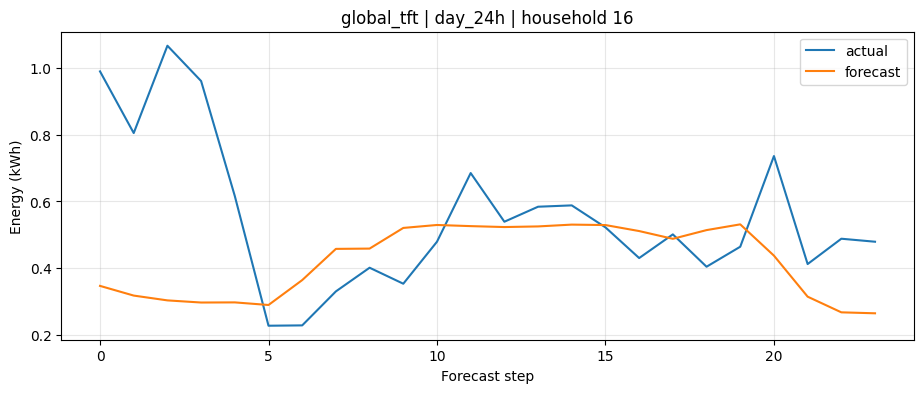

In [21]:
# =========================================
# 11. INSPECT A SAVED FORECAST
# =========================================
import matplotlib.pyplot as plt
import numpy as np

MODEL_TO_INSPECT = "global_tft"
TASK_TO_INSPECT = "day_24h"

sample_path = (
    RUNS_DIR
    / MODEL_TO_INSPECT
    / TASK_TO_INSPECT
    / "prediction_sample.npz"
)

if sample_path.exists():
    sample = np.load(sample_path)

    plt.figure(figsize=(11, 4))
    plt.plot(sample["target"][0], label="actual")
    plt.plot(sample["prediction"][0], label="forecast")
    plt.xlabel("Forecast step")
    plt.ylabel("Energy (kWh)")
    plt.title(
        f"{MODEL_TO_INSPECT} | {TASK_TO_INSPECT} | "
        f"household {int(sample['household'][0])}"
    )
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()
else:
    print("Sample not found:", sample_path)


## Final promotion checklist

Do not promote a checkpoint merely because the training process completed. For each horizon:

1. prioritize cold-start macro MAE;
2. confirm positive improvement over seasonal naive;
3. inspect the percentage of households beating seasonal naive;
4. compare median and p90 household MAE;
5. confirm known-household performance;
6. consider inference cost and checkpoint size;
7. export the primary and fallback checkpoints with complete registry metadata.

The application should expose only **Next day**, **Next week**, and **Next month**. Architecture selection remains a backend registry responsibility.
